# Epidemic-forest pipeline — South Cotabato / General Santos dengue

End-to-end, VS Code–runnable pipeline for the city-level dengue epidemic forest,
with the **ensemble stability** and **LGU out-degree index (LOI)**
computation wired in as one function (`epidemic_forest_ensemble`).

**What this notebook does**
1. Builds daily case matrices per year from the DOH Excel workbook.
2. Merges years and smooths with a centred moving-average filter of span 60
   (`moving_average`, verified to reproduce `SmoothMergedData.mat` to ~1e-15).
3. Estimates per-LGU onset dates by fitting the Richards curve.
4. Reconstructs the epidemic forest as a Monte-Carlo ensemble over a
   probabilistic distance-decay connectivity network, and — in a single call —
   returns modal parents, **per-edge stability**, and **$\mathrm{LOI}$** per period,
   plus cross-period recurrence.
5. Writes two tidy tables to CSV: `edge_stability.csv` and `city_reproduction_Rc.csv`.

**Requirements**: `numpy pandas scipy openpyxl` (all in a standard scientific env,
e.g. your `pinnsir_arm` conda env). `matplotlib` is optional (only for the
heatmap cell).

**Data**: set `DATA_DIR` below to the folder containing
`South_Cotabato_General Santos.xlsx`. Onsets and smoothing are computed natively in Python; cached intermediates (`SmoothMergedData.mat`, `NormalizedOnset.mat`) are optional and only speed up re-runs.


## 📄 Manuscript map

This notebook is the reproducible pipeline behind the manuscript
*"Adapting the region-scale epidemic forest for city-level dengue surveillance..."*
Each section below is annotated with the manuscript element it produces or implements.

| Notebook section | Manuscript element |
|---|---|
| 0. Configuration | Parameters (consolidated as **Table 3**): threshold 25/100k **Eq. (1)**, λ in $P_{ij}=e^{-λ d}$ **Eq. (4)**, SoL weights α=β=⅓ **Eq. (5)**, incubation 5 d, M=5000 |
| 1. Constants (LGUs, pop, coords) | **Table 2** |
| 2 & 4. Smoothing / merge | preprocessing; underlies **Fig. 1** |
| 3. Daily case matrices | Data section (DOH workbook) |
| 5. Onset estimation (Richards) | **Eq. (1)** threshold, **Eq. (2)** Richards, **Eq. (3)** onset |
| 6. Ensemble reconstruction | §2.3.4 (algorithm) — **Eq. (4)** network $P_{ij}$, **Eq. (5)** SoL (derived in **Appendix A**), **Eq. (6)** parent, **Eq. (7)** $LBR$, **Eq. (8)** $\mathrm{LOI}$ |
| 7–8. Tables + end-to-end run | **Table 4** (stability), **Table 5** ($\mathrm{LOI}$); global $LBR$ = 5/2/5; writes both CSVs |
| 9. Heatmap (original + clustered) | **Fig. 1** (both panels) |
| 10. Forest maps | **Fig. 3** (per-period modal forests) |
| 11. Weight sensitivity | **Table 6** / §3.4 |
| 12. Onset vs incidence | **Fig. 2** |
| 13. Cross-province transferability | **Table 10** / §3.5 (preliminary) |
| 14. Connectivity robustness | **Table 7** + **Fig. 4** / §3.4 |
| 15. Smoothing-window sensitivity | **Table 8** / §3.4 |

**Figure 2** (standardised onset vs per-capita incidence, pooled $r=-0.67$) is drawn in Section 12 (also available as the standalone `make_onset_scatter.py`). **Figure 3** (per-period forest maps) is reproduced by Section 10 (`plot_modal_forest`, writing `figures/forest_period{1,2,3}.png`); the manuscript Fig. 3 **now uses these** (re-run §10 with internet to restore the terrain basemap).

_Outputs written by a full run: `edge_stability.csv` (Table 4),
`city_reproduction_Rc.csv` (Table 5), `weight_sensitivity.csv` (Table 6), `kernel_robustness.csv` (Table 7), `smoothing_sensitivity.csv` (Table 8), `onset_threshold.csv` (Table 9)._


## 0. Configuration

> **Manuscript:** parameters used throughout — outbreak threshold 25 per 100 000 (Eq. 1), distance-decay λ in $P_{ij}=e^{-λ d}$ (Eq. 4), Strength-of-Linkage weights α=β=⅓ (Eq. 5), incubation 5 days, ensemble size M=5000.


In [2]:
from pathlib import Path

# Folder holding "South_Cotabato_General Santos.xlsx" (and optionally the .mat files)
DATA_DIR = Path("/Users/jayroldarcede/Documents/Nuning-Jayrold-Maria-paper")

XLSX = DATA_DIR / "South_Cotabato_General Santos.xlsx"

# Reproducibility / behaviour flags
USE_SHIPPED_SMOOTH = True   # if the cached smoothed series exists, load it
USE_SHIPPED_ONSET  = False   # optional cached onsets; default recomputes in Python
KMAX      = 5000            # network realisations in the ensemble
SEED      = 0              # RNG seed -> reproducible ensemble
SMOOTH_SPAN   = 60
INCUBATION    = 5
ALPHA_DIST    = 5.0        # lambda in the distance-decay network  P_ij = exp(-lambda d)
ALPHA_W = BETA_W = 1/3     # spatial / temporal weights in the SoL
SOL_MODE = "nasution"      # "nasution": harmonised Eq. 5 (maximise 1/dist_norm-by-min + prevalence
                          #   difference); "current": original implemented (mean-normalised, minimised) form

# Onsets are computed natively in Python (Sobol starts + L-BFGS-B on the Richards curve).


## 1. Constants (equivalent of `muncity_list.m`)

> **Manuscript:** the twelve LGUs with populations and coordinates — Table 2.


In [3]:
import numpy as np
import pandas as pd
from scipy.io import loadmat, savemat

def _meta_from_csv(csv_rel):
    """Load LGU list, 2015 population, and coordinates from Data/<Province>_lgus.csv."""
    m = pd.read_csv(DATA_DIR / csv_rel)
    lgus  = m["LGU"].astype(str).str.upper().str.replace("\u00d1", "N").tolist()
    pop   = m["Population_2015"].to_numpy(float)
    coord = m[["Latitude", "Longitude"]].to_numpy(float)
    return lgus, pop, coord

# ---- Province registry ----------------------------------------------------
#   source="shipped" -> South_Cotabato workbook + shipped .mat (exact manuscript path)
#   source="chd12"   -> extract from CHD12 line-list; metadata from Data/<Province>_lgus.csv
PROVINCES = {
  "south_cotabato": dict(
     name="South Cotabato + General Santos City",
     lgus=["BANGA","KORONADAL CITY","LAKE SEBU","NORALA","POLOMOLOK","SANTO NINO",
           "SURALLAH","TBOLI","TAMPAKAN","TANTANGAN","TUPI","GENERAL SANTOS CITY"],
     population=[89164,195398,87442,44642,152589,39796,89340,91453,41018,45744,73459,697315],
     coordinates=[[6.4235,124.7734],[6.5003,124.8435],[6.2248,124.7118],[6.5188,124.6567],
                  [6.2142,125.0644],[6.4380,124.6734],[6.3756,124.7472],[6.2136,124.8226],
                  [6.4439,124.9272],[6.5632,124.7682],[6.3310,124.9508],[6.1200,125.1700]],
     periods=[(115,319),(509,800),(1549,1796)], source="shipped"),
  # --- validation provinces (Region-12 CHD12 line-list); metadata from CSVs ---
  "north_cotabato": dict(name="North Cotabato", chd12_province="NORTH COTABATO",
     metadata_csv="Data/North_Cotabato_lgus.csv",
     periods=[(115,319),(509,800),(1549,1796)], source="chd12"),
  "sultan_kudarat": dict(name="Sultan Kudarat", chd12_province="SULTAN KUDARAT",
     metadata_csv="Data/Sultan_Kudarat_lgus.csv",
     periods=[(115,319),(509,800),(1549,1796)], source="chd12"),
  "sarangani": dict(name="Sarangani", chd12_province="SARANGANI",
     metadata_csv="Data/Sarangani_lgus.csv",
     periods=[(115,319),(509,800),(1549,1796)], source="chd12"),
}

ACTIVE_PROVINCE = "south_cotabato"     # <- switch province here; default = manuscript run
PROVINCE = PROVINCES[ACTIVE_PROVINCE]
if PROVINCE["source"] == "chd12":
    CITIES, POPULATION, COORDINATES = _meta_from_csv(PROVINCE["metadata_csv"])
    POPULATION = np.asarray(POPULATION, float)
else:
    CITIES = list(PROVINCE["lgus"]); POPULATION = np.array(PROVINCE["population"], float)
    COORDINATES = np.array(PROVINCE["coordinates"], float)
N = len(CITIES); YEARS = [2015,2016,2017,2018,2019,2020]; PERIODS = PROVINCE["periods"]
print(f"[{ACTIVE_PROVINCE}] {N} LGUs; periods = {PERIODS}")

# outputs -> DATA_DIR for the manuscript province, else a per-province subfolder
OUTDIR = DATA_DIR if ACTIVE_PROVINCE == "south_cotabato" else (DATA_DIR / ACTIVE_PROVINCE)
FIGDIR = OUTDIR / "figures"
OUTDIR.mkdir(parents=True, exist_ok=True); FIGDIR.mkdir(parents=True, exist_ok=True)


[south_cotabato] 12 LGUs; periods = [(115, 319), (509, 800), (1549, 1796)]


In [4]:
# ---- CHD12 line-list loader (used when PROVINCE["source"] == "chd12") ------
def load_province_daily(chd12_province, cities, data_dir=None):
    """Extract a province from the CHD12 DOH line-list into a (T, N) daily matrix,
    columns aligned to `cities` order. Days span 2015-01-01..2020-12-31 (T=2192)."""
    from pathlib import Path
    dd = Path(data_dir) if data_dir else DATA_DIR
    db = dd / "Data" / "CHD12 DENGUE MDB 2015-2021.xlsx"
    def _norm(s):
        s = str(s).strip().upper().replace("\u00d1", "N")
        return {"BANG": "BANGA", "PIGKAWAYAN": "PIGCAWAYAN"}.get(s, s)
    prov = _norm(chd12_province); frames = []
    for y in [2015, 2016, 2017, 2018, 2019, 2020]:
        d = pd.read_excel(db, sheet_name=str(y), usecols=["Province", "Muncity", "DOnset"],
                          engine="openpyxl")
        d["P"] = d["Province"].map(_norm); d["M"] = d["Muncity"].map(_norm)
        d = d[d["P"] == prov].copy()
        d["DOnset"] = pd.to_datetime(d["DOnset"], errors="coerce")
        frames.append(d.dropna(subset=["DOnset"]))
    df = pd.concat(frames, ignore_index=True)
    df = df[(df["DOnset"] >= "2015-01-01") & (df["DOnset"] <= "2020-12-31")]
    ref = pd.date_range("2015-01-01", "2020-12-31", freq="D")
    cols = [_norm(c) for c in cities]
    daily = (df.groupby(["DOnset", "M"]).size().rename("n").reset_index()
               .pivot(index="DOnset", columns="M", values="n")
               .reindex(index=ref, columns=cols).fillna(0).astype(float))
    return daily.to_numpy()


## 2. Centred moving-average smoothing (span 60)

> **Manuscript:** corrected smoothing of the daily series (preprocessing); the smoothed series underlies Fig. 1 and every downstream step.

`pandas.rolling(60, center=True, min_periods=1).mean()` does **not** equal
Python `smooth`. Python reduces an even span 60 to odd 59 and uses a symmetric
shrinking window at the series edges. `moving_average` below reproduces
`SmoothMergedData.mat` to machine precision.

In [5]:
def moving_average(x, span=60):
    # Centred moving-average of span `span` (standard 'moving' convention).
    x = np.asarray(x, float); n = x.size
    if span % 2 == 0:
        span -= 1
    max_odd = n if n % 2 == 1 else n - 1
    span = min(span, max_odd)
    half = (span - 1) // 2
    c = np.cumsum(np.insert(x, 0, 0.0))
    out = np.empty(n)
    for i in range(n):
        w = min(i, n - 1 - i, half)          # symmetric shrinking at edges
        out[i] = (c[i + w + 1] - c[i - w]) / (2 * w + 1)
    return out


## 3. Build daily case matrices per year

> **Manuscript:** data preparation from the DOH daily case workbook (Data section).


In [6]:
def build_daily_matrices(excel_path=XLSX, years=YEARS, save=False):
    mats = {}
    for year in years:
        raw = pd.read_excel(excel_path, sheet_name=str(year), header=None,
                            engine="openpyxl")
        city = raw.iloc[1:, 1].astype(str).str.strip()            # column B
        onset = pd.to_datetime(raw.iloc[1:, 4], format="%d/%m/%Y",  # column E
                               errors="coerce")
        df = pd.DataFrame({"City": city, "Onset": onset}).dropna(subset=["Onset"])
        ref = pd.date_range(f"{year}-01-01", f"{year}-12-31", freq="D")
        pivot = (df.groupby(["City", "Onset"]).size()
                   .rename("n").reset_index()
                   .pivot(index="Onset", columns="City", values="n")
                   .reindex(index=ref, columns=CITIES).fillna(0).astype(int))
        mats[year] = pivot.to_numpy()
        if save:
            savemat(str(DATA_DIR / f"DailyMat{year}.mat"), {"DaiyMat": mats[year]})
    return mats


## 4. Merge years + smooth (uses `moving_average`)

> **Manuscript:** produces the smoothed temporal–spatial series shown in Fig. 1.


In [7]:
def merge_and_smooth(years=YEARS, span=SMOOTH_SPAN, from_mat_if_present=True):
    # Prefer cached DailyMat*.mat if present, else build from the Excel workbook.
    parts = []
    have_mats = all((DATA_DIR / f"DailyMat{y}.mat").exists() for y in years)
    if from_mat_if_present and have_mats:
        for y in years:
            parts.append(np.atleast_2d(loadmat(str(DATA_DIR / f"DailyMat{y}.mat"))["DaiyMat"]))
    else:
        mats = build_daily_matrices()
        parts = [np.atleast_2d(mats[y]) for y in years]
    merged = np.vstack(parts).astype(float)
    smoothed = np.column_stack([moving_average(merged[:, j], span) for j in range(merged.shape[1])])
    return merged, smoothed


### (optional) verify the moving-average against the cached smoothed series

> **Reproducibility check:** reproduces the shipped Python `SmoothMergedData.mat` to ~7e-15 (machine precision).
Runs only if `SmoothMergedData.mat` is present.

In [8]:
smd_path = DATA_DIR / "SmoothMergedData.mat"
if smd_path.exists():
    S_ref = loadmat(str(smd_path))["SmoothMergedData"].astype(float)
    _, S_new = merge_and_smooth()
    err = np.abs(S_new - S_ref).max()
    print(f"max |moving-average - cached smoothed series| = {err:.2e}",
          "  (machine precision ✔)" if err < 1e-9 else "  (MISMATCH!)")
else:
    print("SmoothMergedData.mat not found — skipping verification.")


max |moving-average - cached smoothed series| = 7.11e-15   (machine precision ✔)


## 5. Onset estimation (Richards curve)

> **Manuscript:** Eq. (1) outbreak threshold, Eq. (2) Richards curve, Eq. (3) onset date. Onsets feed Fig. 2 (onset vs incidence) and the forest reconstruction.

Fits the generalised-logistic (Richards) curve to each LGU's cumulative series per
period and reads the onset as the first crossing of the population threshold
$\theta_i = 25\,N_i/100000$, then normalises by the per-period minimum.

In [9]:
from scipy.optimize import minimize
from scipy.stats import qmc
import warnings

def DynK(t, p):
    C1, C2, C3, C4 = p
    return C1 / (1.0 + C2 * np.exp(-C3 * (t - C4))) ** (1.0 / C2)

def _cost(p, t, d):
    return np.sum((DynK(t, p) - d) ** 2)

def _sobol_starts(n, cumdata):
    s = qmc.Sobol(d=4, scramble=False); s.random(1000)   # ~ Python Skip 1e3
    X = s.random(n)
    X[:, 0] = 2.0 * cumdata.max() * X[:, 0]
    X[:, 1] = 0.1 * X[:, 1]
    X[:, 3] = 1000.0 * X[:, 3]
    return X

def extract_onsets(smoothed, n_starts=2048):
    point_prev = POPULATION * (25.0 / 100000.0)
    bounds = [(0, None), (0.005, None), (0, None), (0, None)]
    Onset = np.zeros((N, len(PERIODS)))
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for K, (a, b) in enumerate(PERIODS):
            cum = np.cumsum(smoothed[a:b, :], axis=0)
            t = np.arange(cum.shape[0], dtype=float)
            for i in range(N):
                cd = cum[:, i]
                G = _sobol_starts(n_starts, cd)
                x0 = G[np.argmin([_cost(g, t, cd) for g in G])]
                res = minimize(_cost, x0, args=(t, cd), method="L-BFGS-B",
                               bounds=bounds, options={"maxiter": 5000})
                dyn = DynK(t, res.x)
                hit = np.where(dyn >= point_prev[i])[0]
                Onset[i, K] = hit[0] if hit.size else np.inf
    NO = np.zeros_like(Onset)
    for j in range(Onset.shape[1]):
        col = Onset[:, j]; fin = col[np.isfinite(col)]
        NO[:, j] = col - (fin.min() if fin.size else 0.0)
    return NO

def get_normalized_onset(smoothed):
    # Exact-reproducibility cache. The onset optimiser (Sobol + L-BFGS-B) is not
    # bit-identical across SciPy versions, so we cache the computed onsets to a CSV:
    # the FIRST run writes `normalized_onset.csv`; COMMIT that file, and every later
    # run -- on any machine -- loads it and reproduces identical tables and figures.
    cache = OUTDIR / "normalized_onset.csv"
    if cache.exists():
        print(f"Loading cached onsets from {cache.name} (exact reproducibility).")
        return pd.read_csv(cache).to_numpy(float)
    print("Computing onsets in Python (Sobol + L-BFGS-B) and caching to normalized_onset.csv ...")
    NO = extract_onsets(smoothed)
    pd.DataFrame(NO, columns=[f"P{k+1}" for k in range(NO.shape[1])]).to_csv(cache, index=False)
    print(f"  saved {cache.name} -- COMMIT this file so re-runs and other machines reproduce identical results.")
    return NO


## 6. Epidemic forest — ensemble reconstruction (**the wired-in function**)

> **Manuscript:** §2.3.4. Eq. (4) connectivity network $P_{ij}=e^{-λ d}$, Eq. (5) Strength of Linkage, Eq. (6) parent assignment, Eq. (7) global $LBR$, Eq. (8) LGU out-degree index (LOI).

`epidemic_forest_ensemble` runs the whole Monte-Carlo reconstruction and returns,
per period: the full parent distribution, the modal parent and its **stability**,
the **LGU out-degree index (LOI)**, and period-level counts / global $LBR$.
Everything the stability and $\mathrm{LOI}$ tables need comes out of this one call.

In [10]:
from collections import Counter

def _dist(a, B):
    a = np.asarray(a).reshape(1, 2); B = np.asarray(B).reshape(-1, 2)
    return np.sqrt((a[0, 0] - B[:, 0]) ** 2 + (a[0, 1] - B[:, 1]) ** 2)

def epidemic_forest_ensemble(smoothed, normalized_onset, kMax=KMAX,
                             incubation=INCUBATION, alpha_dist=ALPHA_DIST,
                             alpha_w=ALPHA_W, beta_w=BETA_W, seed=SEED):
    # Monte-Carlo epidemic-forest reconstruction.
    # Returns a list (one dict per period) with keys:
    #   parent_dist  : {child_idx: Counter(parent_1based -> count)}   (0 = primary)
    #   modal_parent : (N,) int    modal parent, 1-based (0 = primary)
    #   stability    : (N,) float  fraction of runs selecting the modal parent
    #   R_c          : (N,) int    children seeded by each LGU in the modal forest
    #   n_primaries, n_children, global_Rt
    rng = np.random.default_rng(seed)
    prob_dis = lambda d: np.exp(-alpha_dist * d)
    results = []
    for K, (a, b) in enumerate(PERIODS):
        cum = np.cumsum(smoothed[a:b, :], axis=0)
        cum_cities = cum.T                                   # (N, Tp)
        onset = normalized_onset[:, K].astype(int)
        loops = np.zeros((kMax, N), dtype=int)
        for L in range(kMax):
            adj = np.zeros((N, N), dtype=int)
            for i in range(N):
                for j in range(i + 1, N):
                    if rng.random() < prob_dis(_dist(COORDINATES[i], COORDINATES[j])[0]):
                        adj[i, j] = adj[j, i] = 1
            children = list(range(N)); parent = np.zeros(N, dtype=int)
            while children:
                c = children.pop(rng.integers(len(children)))
                Tc = onset[c]
                cand = np.where(adj[c] == 1)[0]
                cand = cand[onset[cand] < Tc - incubation]
                if cand.size:
                    Ti = int(np.clip(Tc, 0, cum_cities.shape[1] - 1))
                    if SOL_MODE == "nasution":
                        # Nasution et al. (2024) Eq. 5: maximise inverse min-normalised
                        # distances + normalised prevalence difference.
                        Ds  = _dist(COORDINATES[c], COORDINATES[cand])
                        Dt  = (Tc - onset[cand]).astype(float)          # > incubation > 0
                        Dsn = Ds / Ds.min(); Dtn = Dt / Dt.min()
                        Pj  = cum_cities[cand, Ti]; Pc = cum_cities[c, Ti]
                        den = np.max(np.abs(Pj - Pc))
                        Pt  = (Pj - Pc) / den if den > 0 else np.zeros_like(Pj)
                        SoL = alpha_w * (1.0 / Dsn) + beta_w * (1.0 / Dtn) + (1 - alpha_w - beta_w) * Pt
                        parent[c] = int(cand[np.argmax(SoL)]) + 1     # 1-based; greatest SoL
                    else:  # "current": original implemented (mean-normalised, minimised) form
                        Sd = _dist(COORDINATES[c], COORDINATES[cand]).mean()
                        Td = (onset[cand] - Tc).mean()
                        Pd = np.mean(1.0 / cum_cities[cand, Ti])
                        Ws = _dist(COORDINATES[c], COORDINATES[cand]) / Sd
                        Wt = (onset[cand] - Tc) / Td
                        Wp = cum_cities[cand, Ti] / Pd
                        SoL = alpha_w * Ws + beta_w * Wt + (1 - alpha_w - beta_w) * (1.0 / Wp)
                        parent[c] = int(cand[np.argmin(SoL)]) + 1     # 1-based
            loops[L] = parent
        parent_dist = {c: Counter(loops[:, c].tolist()) for c in range(N)}
        modal = np.array([parent_dist[c].most_common(1)[0][0] for c in range(N)])
        stability = np.array([parent_dist[c][modal[c]] / kMax for c in range(N)])
        R_c = np.array([int((modal == i + 1).sum()) for i in range(N)])
        n_prim = int((modal == 0).sum()); n_child = N - n_prim
        results.append(dict(parent_dist=parent_dist, modal_parent=modal,
                            stability=stability, R_c=R_c,
                            n_primaries=n_prim, n_children=n_child,
                            global_Rt=(n_child / n_prim if n_prim else np.inf)))
    return results


## 7. Turn the ensemble result into the two manuscript tables

> **Manuscript:** builds Table 4 (modal parent + stability) and Table 5 ($\mathrm{LOI}$).


In [11]:
def _lab(p):        # 1-based parent index -> label
    return "primary" if p == 0 else CITIES[p - 1]

def build_stability_table(results):
    rows = []
    for c in range(N):
        row = {"Child LGU": CITIES[c]}
        for K in range(len(PERIODS)):
            p = int(results[K]["modal_parent"][c]); s = results[K]["stability"][c]
            row[f"P{K+1} parent"] = _lab(p)
            row[f"P{K+1} stability"] = f"{s:.0%}"
        rows.append(row)
    return pd.DataFrame(rows)

def build_rc_table(results):
    rows = []
    for c in range(N):
        row = {"LGU": CITIES[c]}
        for K in range(len(PERIODS)):
            row[f"P{K+1}"] = int(results[K]["R_c"][c])
        rows.append(row)
    df = pd.DataFrame(rows)
    # order by total children seeded, descending
    df["_tot"] = df[[f"P{k+1}" for k in range(len(PERIODS))]].sum(axis=1)
    return df.sort_values("_tot", ascending=False).drop(columns="_tot").reset_index(drop=True)

def cross_period_recurrence(results):
    rows = []
    for c in range(N):
        trip = tuple(int(results[K]["modal_parent"][c]) for K in range(len(PERIODS)))
        labs = [_lab(p) for p in trip]
        uniq = len(set(trip))
        tag = "ALL-3" if uniq == 1 else ("2/3" if max(Counter(trip).values()) >= 2 else "varies")
        rows.append({"Child LGU": CITIES[c], **{f"P{k+1}": labs[k] for k in range(3)}, "recurrence": tag})
    return pd.DataFrame(rows)


## 8. Run the pipeline end-to-end

> **Manuscript:** end-to-end run; reports global $LBR$ = 5.0 / 2.0 / 5.0 for Periods 1–3 and writes `edge_stability.csv` (Table 4) and `city_reproduction_Rc.csv` (Table 5).

This rebuilds the smoothed series with the corrected `moving_average`, obtains the
onsets, runs the `KMAX`-realisation ensemble, and displays + saves the two tables.
With `KMAX=5000` this takes a short while; drop `KMAX` in the config cell for a
quick smoke test.

In [12]:
# smoothing: branch on the active province's data source --------------------
if PROVINCE["source"] == "shipped":
    merged, smoothed = merge_and_smooth()
    if USE_SHIPPED_SMOOTH and (DATA_DIR / "SmoothMergedData.mat").exists():
        smoothed = loadmat(str(DATA_DIR / "SmoothMergedData.mat"))["SmoothMergedData"].astype(float)
else:  # "chd12" validation province: extract from the line-list, then moving_average
    daily = load_province_daily(PROVINCE["chd12_province"], CITIES)
    smoothed = np.column_stack([moving_average(daily[:, j], SMOOTH_SPAN) for j in range(N)])
    print(f"[{ACTIVE_PROVINCE}] extracted + smoothed from CHD12:", smoothed.shape)
print("smoothed series:", smoothed.shape)

# onsets need PERIODS; the ensemble additionally needs COORDINATES -----------
if PERIODS is None:
    print("PERIODS not set -- view the clustered heatmap to pick outbreak windows, "
          "then set PROVINCE['periods'] in the config.")
    NO = results = None
else:
    NO = get_normalized_onset(smoothed) if PROVINCE["source"] == "shipped" else extract_onsets(smoothed)
    if COORDINATES is None:
        print("COORDINATES not set -- fill Data/<Province>_lgus.csv to run the ensemble.")
        results = None
    else:
        results = epidemic_forest_ensemble(smoothed, NO, kMax=KMAX, seed=SEED)
        for K, r in enumerate(results, 1):
            print(f"Period {K}: primaries={r['n_primaries']} children={r['n_children']} "
                  f"global LBR={r['global_Rt']:.2f}")


smoothed series: (2192, 12)
Computing onsets in Python (Sobol + L-BFGS-B) and caching to normalized_onset.csv ...
  saved normalized_onset.csv -- COMMIT this file so re-runs and other machines reproduce identical results.
Period 1: primaries=2 children=10 global R_t=5.00
Period 2: primaries=5 children=7 global R_t=1.40
Period 3: primaries=2 children=10 global R_t=5.00


### Edge-stability table

> **Manuscript:** Table 4.


In [13]:
stab = build_stability_table(results)
stab.to_csv(OUTDIR / "edge_stability.csv", index=False)
stab


,Child LGU,P1 parent,P1 stability,P2 parent,P2 stability,P3 parent,P3 stability
0,BANGA,KORONADAL CITY,60%,primary,64%,TANTANGAN,48%
1,KORONADAL CITY,TUPI,38%,primary,63%,TANTANGAN,53%
2,LAKE SEBU,TBOLI,58%,TBOLI,32%,TBOLI,38%
3,NORALA,KORONADAL CITY,40%,KORONADAL CITY,40%,BANGA,47%
4,POLOMOLOK,TUPI,40%,TUPI,45%,TUPI,28%
5,SANTO NINO,SURALLAH,62%,SURALLAH,62%,SURALLAH,62%
6,SURALLAH,primary,100%,primary,65%,BANGA,77%
7,TBOLI,SURALLAH,31%,TUPI,41%,SURALLAH,30%
8,TAMPAKAN,KORONADAL CITY,61%,KORONADAL CITY,61%,primary,63%
9,TANTANGAN,KORONADAL CITY,61%,KORONADAL CITY,61%,primary,100%


### LGU out-degree index (LOI)

> **Manuscript:** Table 5.


In [14]:
rc = build_rc_table(results)
rc.to_csv(OUTDIR / "city_reproduction_Rc.csv", index=False)
rc


,LGU,P1,P2,P3
0,KORONADAL CITY,4,3,0
1,SURALLAH,2,1,2
2,TUPI,2,2,1
3,BANGA,0,0,3
4,TBOLI,1,1,1
5,POLOMOLOK,1,0,1
6,TANTANGAN,0,0,2
7,LAKE SEBU,0,0,0
8,NORALA,0,0,0
9,SANTO NINO,0,0,0


### Cross-period recurrence (which modal edges repeat)

> **Manuscript:** supports the Discussion — only Lake Sebu ← T'boli is the modal parent in all three periods.


In [15]:
cross_period_recurrence(results)


,Child LGU,P1,P2,P3,recurrence
0,BANGA,KORONADAL CITY,primary,TANTANGAN,varies
1,KORONADAL CITY,TUPI,primary,TANTANGAN,varies
2,LAKE SEBU,TBOLI,TBOLI,TBOLI,ALL-3
3,NORALA,KORONADAL CITY,KORONADAL CITY,BANGA,2/3
4,POLOMOLOK,TUPI,TUPI,TUPI,ALL-3
5,SANTO NINO,SURALLAH,SURALLAH,SURALLAH,ALL-3
6,SURALLAH,primary,primary,BANGA,2/3
7,TBOLI,SURALLAH,TUPI,SURALLAH,2/3
8,TAMPAKAN,KORONADAL CITY,KORONADAL CITY,primary,2/3
9,TANTANGAN,KORONADAL CITY,KORONADAL CITY,primary,2/3


## 9. Heatmap of the smoothed series — original + clustered (Fig. 1)

> **Manuscript:** reproduces **Fig. 1** (both panels). *Top:* LGUs in their original
> order. *Bottom:* LGUs reordered by hierarchical clustering to highlight temporal
> coherence. The clustering (`matlab_cluster_order`) is a faithful Python port of the
> Python agglomerative scheme (centroid distance between cluster mean-series,
> normalised by summed means, column-major tie-break) and reproduces the leaf order
> of the shipped `clusternew.jpg` exactly. Colour map is green (`Greens`); brighter =
> higher burden. Writes `figures/heatmap_two_panel.png`.


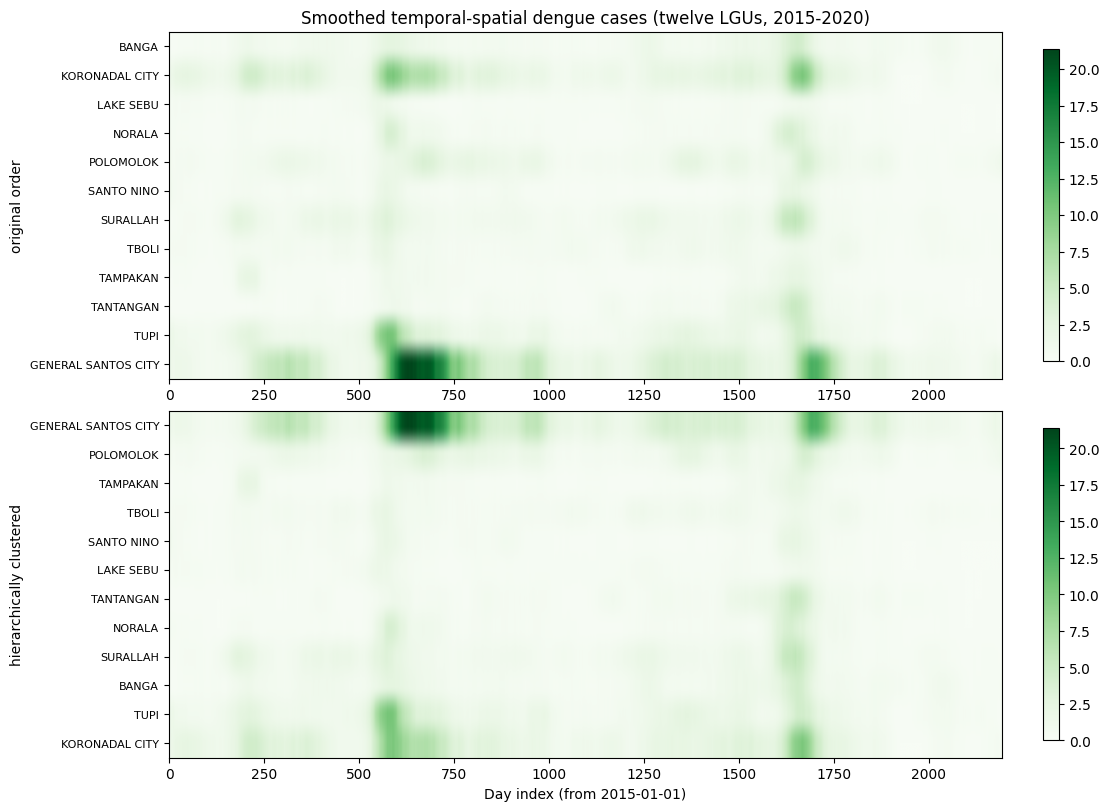

clustered LGU order: ['GENERAL SANTOS CITY', 'POLOMOLOK', 'TAMPAKAN', 'TBOLI', 'SANTO NINO', 'LAKE SEBU', 'TANTANGAN', 'NORALA', 'SURALLAH', 'BANGA', 'TUPI', 'KORONADAL CITY']
wrote /Users/jayroldarcede/Documents/Nuning-Jayrold-Maria-paper/figures/heatmap_two_panel.png


In [16]:
import matplotlib.pyplot as plt

def matlab_cluster_order(smoothed):
    """Faithful port of the Python Step_3 agglomerative clustering leaf order.

    Distance between clusters i,j is the SSD of their mean time-series divided by
    the sum of their overall means; the closest pair is merged each step. Tie-break
    follows Python's column-major find(). Reproduces clusternew.jpg's LGU order.
    """
    N = smoothed.shape[1]
    clusters = [smoothed[:, [i]].copy() for i in range(N)]
    cidx = [[i] for i in range(N)]
    while len(clusters) > 1:
        m = len(clusters)
        meanTS = [c.mean(axis=1) for c in clusters]
        omean  = [c.mean() for c in clusters]
        Sim = np.full((m, m), np.nan)
        for i in range(m):
            for j in range(m):
                if i != j:
                    Sim[i, j] = ((meanTS[i] - meanTS[j]) ** 2).sum() / (omean[i] + omean[j])
        val = np.nanmin(Sim)
        matches = [(r, c) for c in range(m) for r in range(m) if Sim[r, c] == val]
        a, b = matches[0][0], matches[1][0]
        merged = np.concatenate([clusters[a], clusters[b]], axis=1)
        keep = [k for k in range(m) if k != a and k != b]
        clusters = [merged] + [clusters[k] for k in keep]
        cidx = [cidx[a] + cidx[b]] + [cidx[k] for k in keep]
    return cidx[0]

order = matlab_cluster_order(smoothed)

fig, axes = plt.subplots(2, 1, figsize=(11, 8), constrained_layout=True)
for ax, idx, subtitle in [(axes[0], list(range(N)), "original order"),
                          (axes[1], order,           "hierarchically clustered")]:
    im = ax.imshow(smoothed[:, idx].T, aspect="auto", origin="upper", cmap="Greens")
    ax.set_yticks(range(N)); ax.set_yticklabels([CITIES[i] for i in idx], fontsize=8)
    ax.set_ylabel(subtitle)
    fig.colorbar(im, ax=ax, shrink=0.9)
axes[0].set_title("Smoothed temporal-spatial dengue cases (twelve LGUs, 2015-2020)")
axes[1].set_xlabel("Day index (from 2015-01-01)")
out = FIGDIR / "heatmap_two_panel.png"
(FIGDIR).mkdir(exist_ok=True)
fig.savefig(out, dpi=200); plt.show()
print("clustered LGU order:", [CITIES[i] for i in order])
print("wrote", out)


## 10. Modal epidemic forest maps (Fig. 3)

> **Manuscript:** reproduces **Fig. 3** — the per-period modal epidemic forests (§2.3.4).
> Nodes are placed at each LGU's coordinates; **node size and colour scale with the
> period's cumulative burden**; **arrows point from each modal parent to its child**
> (primaries have no incoming arrow); **arrow width scales with edge stability**.
> Saves `figures/forest_period{1,2,3}.png`. (The manuscript currently shows the Python
> `Epi*.jpg`, which additionally carry a terrain basemap; these Python maps are the
> reproducible equivalent from the pipeline.)


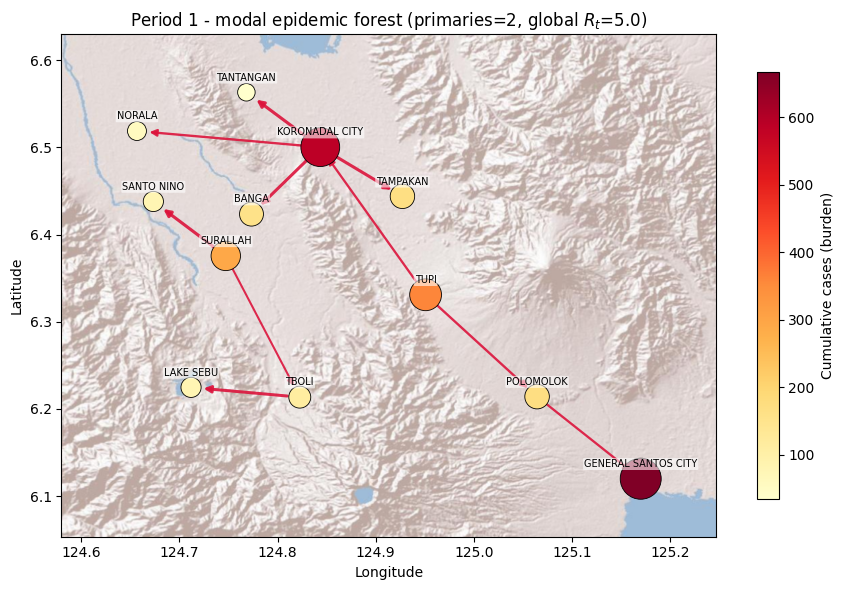

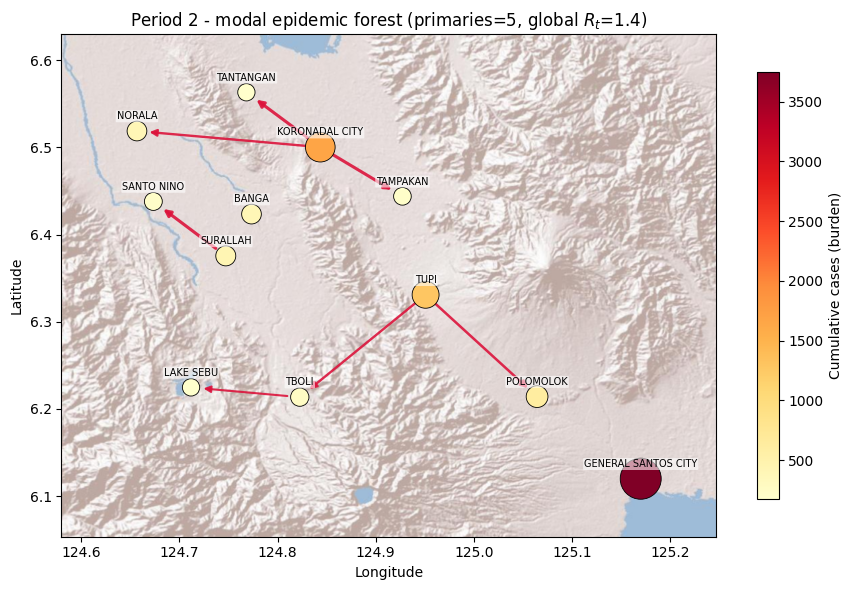

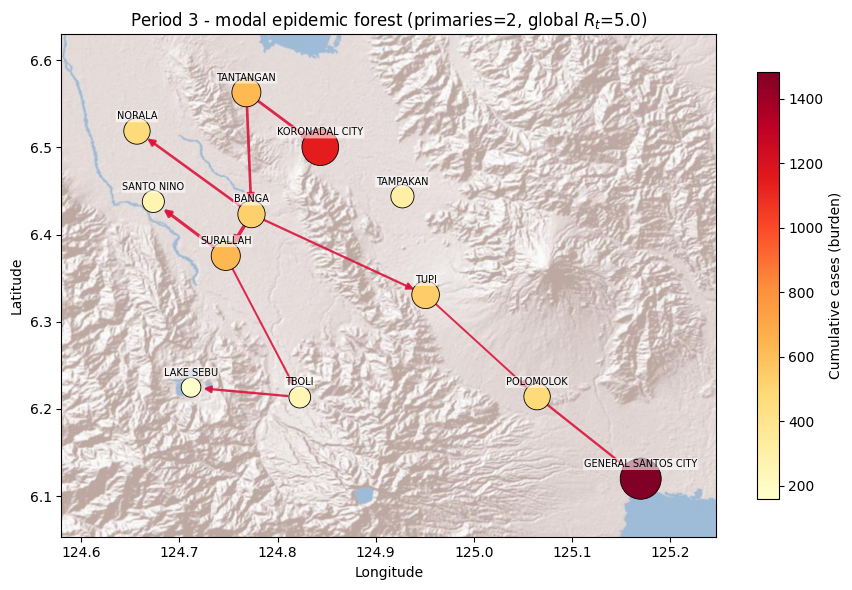

wrote:
  /Users/jayroldarcede/Documents/Nuning-Jayrold-Maria-paper/figures/forest_period1.png
  /Users/jayroldarcede/Documents/Nuning-Jayrold-Maria-paper/figures/forest_period2.png
  /Users/jayroldarcede/Documents/Nuning-Jayrold-Maria-paper/figures/forest_period3.png


In [17]:
import matplotlib.pyplot as plt
try:
    import contextily as ctx
    _HAVE_CTX = True
except Exception:
    _HAVE_CTX = False

def plot_modal_forest(results, smoothed, periods=PERIODS,
                      save_dir=FIGDIR, basemap=True):
    """Draw the modal epidemic forest for each period (reproduces Fig. 3).

    If `basemap` and contextily + internet are available, a shaded-relief terrain
    tile background is drawn (like the original Python Epi*.jpg); otherwise it
    falls back cleanly to a plain lon/lat plot.
    """
    save_dir.mkdir(exist_ok=True)
    lon, lat = COORDINATES[:, 1], COORDINATES[:, 0]
    padx = (lon.max() - lon.min()) * 0.15
    pady = (lat.max() - lat.min()) * 0.15
    xlim = (lon.min() - padx, lon.max() + padx)
    ylim = (lat.min() - pady, lat.max() + pady)
    paths = []
    for K, (a, b) in enumerate(periods):
        burden = smoothed[a:b, :].sum(axis=0)          # cumulative cases in the period
        modal  = results[K]["modal_parent"]            # 1-based parent; 0 = primary
        stab   = results[K]["stability"]

        fig, ax = plt.subplots(figsize=(9, 6))
        ax.set_xlim(*xlim); ax.set_ylim(*ylim)
        ax.set_aspect("auto")   # keep the wide 3:2 frame even with a basemap, so the
                                #   three stacked maps + caption fit the manuscript page

        # terrain basemap behind everything (needs internet; degrades gracefully)
        if basemap and _HAVE_CTX:
            try:
                ctx.add_basemap(ax, crs="EPSG:4326",
                                source=ctx.providers.Esri.WorldShadedRelief,
                                attribution=False)
            except Exception as ex:
                print(f"[Period {K+1}] basemap unavailable "
                      f"({type(ex).__name__}); plotting without it.")

        # directed edges: modal parent -> child, width by stability
        for c in range(N):
            p = int(modal[c])
            if p > 0:
                pi = p - 1
                ax.annotate("", xy=(lon[c], lat[c]), xytext=(lon[pi], lat[pi]),
                            arrowprops=dict(arrowstyle="-|>", color="crimson",
                                            lw=0.7 + 2.5 * stab[c], alpha=0.9,
                                            shrinkA=9, shrinkB=9), zorder=3)
        # nodes sized & coloured by burden
        smax = burden.max() if burden.max() > 0 else 1.0
        sizes = 120 + 750 * (burden / smax)
        sc = ax.scatter(lon, lat, s=sizes, c=burden, cmap="YlOrRd",
                        edgecolor="k", linewidth=0.6, zorder=4)
        for i, name in enumerate(CITIES):
            ax.annotate(name, (lon[i], lat[i]), fontsize=7, ha="center", va="bottom",
                        xytext=(0, 7), textcoords="offset points", zorder=5,
                        bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none", alpha=0.6))
        ax.set_title(f"Period {K+1} - modal epidemic forest "
                     f"(primaries={results[K]['n_primaries']}, "
                     f"global $LBR$={results[K]['global_Rt']:.1f})")
        ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
        cb = fig.colorbar(sc, ax=ax, shrink=0.85); cb.set_label("Cumulative cases (burden)")
        fig.tight_layout()
        out = save_dir / f"forest_period{K+1}.png"
        fig.savefig(out, dpi=200); paths.append(str(out))
        plt.show()
    return paths

forest_paths = plot_modal_forest(results, smoothed)
print("wrote:", *forest_paths, sep="\n  ")


## 11. Sensitivity to the Strength-of-Linkage weights (Table 6)

> **Manuscript:** reproduces **Table 6 / §3.4**. Recomputes the ensemble under the
> eight weight combinations of Nasution et al. (their Table 1), varying
> $\alpha=W_s$, $\beta=W_t$, prevalence $=1-\alpha-\beta$. Shows the findings
> (global $LBR$, GenSan terminal, dominant sources) are robust to the weight choice.
> Writes `figures/../weight_sensitivity.csv`. **Slowest cell** (~1-2 min at
> `KMAX=5000`; lower `kMax` for a quick look). Requires `SOL_MODE="nasution"`.


In [18]:
# eight weight combinations from Nasution et al. (their Table 1): (Ws, Wt, Wp)
COMBOS = {1:(1/3,1/3,1/3), 2:(.10,.45,.45), 3:(.45,.10,.45), 4:(.25,.50,.25),
          5:(.15,.70,.15), 6:(.45,.45,.10), 7:(.25,.25,.50), 8:(.15,.15,.70)}
GEN = CITIES.index("GENERAL SANTOS CITY")

def weight_sensitivity(combos=COMBOS, kMax=KMAX):
    """Recompute the ensemble for each weight combination (reproduces Table 5)."""
    rows = []
    for cid, (Ws, Wt, Wp) in combos.items():
        res = epidemic_forest_ensemble(smoothed, NO, kMax=kMax, alpha_w=Ws, beta_w=Wt)
        meanstab = float(np.mean([res[k]["stability"].mean() for k in range(len(PERIODS))]))
        dom = []
        for k in range(len(PERIODS)):
            i = int(np.argmax(res[k]["R_c"])); dom.append(f"{CITIES[i]} ({int(res[k]['R_c'][i])})")
        rows.append({"combo": cid, "Ws": round(Ws,2), "Wt": round(Wt,2), "Wp": round(Wp,2),
                     "mean_stability": round(meanstab, 3),
                     "dominant_source_P1_P2_P3": " / ".join(dom),
                     "GenSan_Rc": "/".join(str(int(res[k]["R_c"][GEN])) for k in range(len(PERIODS))),
                     "Rt": "/".join(str(round(res[k]["global_Rt"],1)) for k in range(len(PERIODS)))})
    df = pd.DataFrame(rows)
    df.to_csv(OUTDIR / "weight_sensitivity.csv", index=False)
    return df

sens_df = weight_sensitivity()
sens_df


,combo,Ws,Wt,Wp,mean_stability,dominant_source_P1_P2_P3,GenSan_Rc,Rt
0,1,0.33,0.33,0.33,0.549,KORONADAL CITY (4) / KORONADAL CITY (3) / BANG...,0/0/0,5.0/1.4/5.0
1,2,0.10,0.45,0.45,0.526,KORONADAL CITY (4) / KORONADAL CITY (3) / BANG...,0/0/0,5.0/1.4/5.0
2,3,0.45,0.10,0.45,0.539,KORONADAL CITY (4) / TUPI (3) / BANGA (3),0/0/0,5.0/1.4/5.0
3,4,0.25,0.50,0.25,0.549,KORONADAL CITY (3) / KORONADAL CITY (3) / BANG...,0/0/0,5.0/1.4/5.0
4,5,0.15,0.70,0.15,0.529,BANGA (2) / KORONADAL CITY (2) / BANGA (3),0/0/0,5.0/1.4/5.0
5,6,0.45,0.45,0.10,0.573,KORONADAL CITY (3) / KORONADAL CITY (3) / BANG...,0/0/0,5.0/1.4/5.0
6,7,0.25,0.25,0.50,0.529,KORONADAL CITY (4) / KORONADAL CITY (3) / TANT...,0/0/0,5.0/1.4/5.0
7,8,0.15,0.15,0.70,0.501,KORONADAL CITY (4) / TUPI (3) / TANTANGAN (4),0/0/0,5.0/1.4/3.0


## 12. Figure 2 - onset time vs per-capita incidence

> **Manuscript:** reproduces **Fig. 2** (§3.2). Standardised onset time vs
> standardised per-capita incidence (cases per 100k population), pooled across the
> three periods; the negative slope (pooled Pearson $r=-0.67$) shows earlier-onset
> LGUs accumulate higher incidence. Writes `figures/onset_vs_cases.png`.
> (Previously a standalone script `make_onset_scatter.py`; now reproduced here so
> every manuscript figure comes from this notebook.)


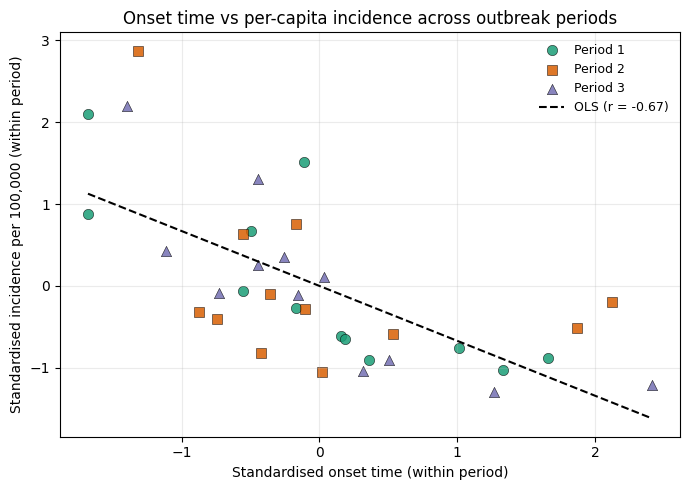

pooled per-capita Pearson r = -0.670, n = 36


In [19]:
import matplotlib.pyplot as plt

def plot_onset_vs_incidence(smoothed, normalized_onset, save=FIGDIR / "onset_vs_cases.png"):
    """Standardised onset vs per-capita incidence across periods (reproduces Fig. 2)."""
    def z(x):
        x = np.asarray(x, float); m = np.isfinite(x); o = np.full_like(x, np.nan)
        o[m] = (x[m] - x[m].mean()) / x[m].std(ddof=0); return o
    fig, ax = plt.subplots(figsize=(7, 5))
    colors = ["#1b9e77", "#d95f02", "#7570b3"]; markers = ["o", "s", "^"]
    ZX, ZY = [], []
    for K, (a, b) in enumerate(PERIODS):
        incidence = smoothed[a:b, :].sum(axis=0) / POPULATION * 1e5   # cases per 100k
        zx, zy = z(normalized_onset[:, K]), z(incidence)
        ax.scatter(zx, zy, c=colors[K], marker=markers[K], s=55, edgecolor="k",
                   linewidth=0.4, alpha=0.85, label=f"Period {K+1}")
        ZX += list(zx); ZY += list(zy)
    ZX, ZY = np.array(ZX), np.array(ZY); m = np.isfinite(ZX) & np.isfinite(ZY)
    r = np.corrcoef(ZX[m], ZY[m])[0, 1]; b1, b0 = np.polyfit(ZX[m], ZY[m], 1)
    xs = np.linspace(ZX[m].min(), ZX[m].max(), 100)
    ax.plot(xs, b0 + b1 * xs, "k--", lw=1.5, label=f"OLS (r = {r:.2f})")
    ax.set_xlabel("Standardised onset time (within period)")
    ax.set_ylabel("Standardised incidence per 100,000 (within period)")
    ax.set_title("Onset time vs per-capita incidence across outbreak periods")
    ax.legend(frameon=False, fontsize=9); ax.grid(alpha=0.25); fig.tight_layout()
    if save: fig.savefig(save, dpi=200)
    plt.show()
    print(f"pooled per-capita Pearson r = {r:.3f}, n = {int(m.sum())}")
    return r

_ = plot_onset_vs_incidence(smoothed, NO)


## 13. Cross-province transferability assessment (Table 10)

> **Manuscript:** reproduces **Table 10 / §3.5** — applies the identical pipeline to
> three further Region-12 provinces from the CHD12 line-list (North Cotabato, Sultan
> Kudarat, Sarangani) and summarises the dominant source in each. **Preliminary:**
> coordinates are GeoNames town centres (`geonames_coords` below; a few estimated),
> Sultan Kudarat / Sarangani populations are provisional, and South Cotabato's outbreak
> windows are reused. Outputs go to `north_cotabato/`, `sultan_kudarat/`, `sarangani/`
> (the manuscript South Cotabato files are never touched). Heavy cell: set
> `RUN_VALIDATION = True` to run (~1–2 min); needs `pip install reverse_geocoder`.


In [20]:
# Reproducible town-centre coordinates from the offline GeoNames dataset.
# Used to build the Latitude/Longitude in Data/<Province>_lgus.csv (coord_status="geonames").
def geonames_coords(lgus, bbox=(5.3, 7.8, 123.7, 125.7),
                    aliases={"SEN NINOY AQUINO": "KULAMAN"}):
    import reverse_geocoder, os, csv, unicodedata
    path = os.path.join(os.path.dirname(reverse_geocoder.__file__), "rg_cities1000.csv")
    def norm(s):
        s = unicodedata.normalize("NFKD", str(s)).encode("ascii","ignore").decode().upper()
        for ch in "'.-": s = s.replace(ch, "")
        return " ".join(s.split())
    la0, la1, lo0, lo1 = bbox
    idx = {}
    for r in csv.DictReader(open(path, encoding="utf-8")):
        if r.get("cc") != "PH": continue
        la, lo = float(r["lat"]), float(r["lon"])
        if la0 <= la <= la1 and lo0 <= lo <= lo1:
            idx.setdefault(norm(r["name"]), (la, lo))
    out = {}
    for lgu in lgus:
        keys = [norm(lgu), norm(lgu).replace(" CITY","").strip()]
        if norm(lgu) in aliases: keys.append(norm(aliases[norm(lgu)]))
        for k in keys:
            if k in idx: out[lgu] = idx[k]; break
    return out


In [21]:
RUN_VALIDATION = False    # set True to reproduce Table 7 (~1-2 min; writes per-province folders)

def run_validation_province(key, kMax=KMAX):
    cfg = PROVINCES[key]
    lgus, pop, coord = _meta_from_csv(cfg["metadata_csv"])
    g = globals()
    g["CITIES"], g["POPULATION"], g["COORDINATES"] = lgus, np.asarray(pop, float), np.asarray(coord, float)
    g["N"], g["PERIODS"] = len(lgus), cfg["periods"]
    outdir = DATA_DIR / key; (outdir / "figures").mkdir(parents=True, exist_ok=True)
    daily = load_province_daily(cfg["chd12_province"], lgus)
    sm = np.column_stack([moving_average(daily[:, j], SMOOTH_SPAN) for j in range(len(lgus))])
    NO = extract_onsets(sm)
    res = epidemic_forest_ensemble(sm, NO, kMax=kMax, seed=SEED)
    build_stability_table(res).to_csv(outdir / "edge_stability.csv", index=False)
    rc = build_rc_table(res); rc.to_csv(outdir / "city_reproduction_Rc.csv", index=False)
    return dict(province=cfg["name"], LGUs=len(lgus), dominant_source=rc.iloc[0]["LGU"],
                Rt=" / ".join(f"{r['global_Rt']:.1f}" for r in res))

if RUN_VALIDATION:
    _sc = {k: globals()[k] for k in ["CITIES","POPULATION","COORDINATES","N","PERIODS"]}
    summary = [run_validation_province(k) for k in ["north_cotabato","sultan_kudarat","sarangani"]]
    globals().update(_sc)      # restore South Cotabato config
    xdf = pd.DataFrame(summary); xdf.to_csv(DATA_DIR / "cross_province_summary.csv", index=False)
    print(xdf.to_string(index=False))
else:
    print("RUN_VALIDATION=False -- set True to run the 3 validation provinces (Table 7).")


RUN_VALIDATION=False -- set True to run the 3 validation provinces (Table 7).


## 14. Robustness to the connectivity model (Table 7, Fig. 4)

Reviewer-requested robustness of the source/sink structure to the connectivity
assumptions: (i) the decay rate `\lambda` swept over an order of magnitude,
(ii) an exponential vs a **Gaussian** kernel matched at its half-probability
distance, and (iii) the probabilistic network vs a fixed **deterministic
adjacency** (Nasution-style). Each setting re-runs the full `M=5000` ensemble
(deterministic case: the single resulting forest). Writes
`kernel_robustness.csv` and `figures/kernel_robustness.png`. Defined for the
primary study area (South Cotabato); harmonised SoL (`SOL_MODE="nasution"`).


In [22]:
import numpy as np
from collections import Counter

def _adj_from_prob(P, rng):
    """Sample an undirected adjacency matrix, one Bernoulli draw per i<j pair
    (same RNG-consumption order as epidemic_forest_ensemble)."""
    Nn = P.shape[0]; adj = np.zeros((Nn, Nn), dtype=int)
    for i in range(Nn):
        for j in range(i + 1, Nn):
            if rng.random() < P[i, j]:
                adj[i, j] = adj[j, i] = 1
    return adj

def epidemic_forest_kernel(smoothed, normalized_onset, kind, par,
                           kMax=KMAX, incubation=INCUBATION,
                           alpha_w=ALPHA_W, beta_w=BETA_W, seed=SEED):
    """Ensemble reconstruction with a configurable connectivity model.
       kind='exp'  -> P_ij = exp(-par * d)          (par = lambda)
       kind='gauss'-> P_ij = exp(-par * d**2)        (par = g)
       kind='det'  -> fixed adjacency d_ij < par     (par = distance threshold, deg)
    The parent rule is identical to epidemic_forest_ensemble() with SOL_MODE='nasution'."""
    rng = np.random.default_rng(seed)
    D = np.vstack([_dist(COORDINATES[i], COORDINATES) for i in range(N)])
    results = []
    for K, (a, b) in enumerate(PERIODS):
        cum_cities = np.cumsum(smoothed[a:b, :], axis=0).T
        onset = normalized_onset[:, K].astype(int)
        det = (kind == 'det')
        P = None if det else (np.exp(-par * D) if kind == 'exp' else np.exp(-par * D**2))
        runs = 1 if det else kMax
        loops = np.zeros((runs, N), dtype=int)
        for L in range(runs):
            if det:
                adj = (D < par).astype(int); np.fill_diagonal(adj, 0)
            else:
                adj = _adj_from_prob(P, rng)
            children = list(range(N)); parent = np.zeros(N, dtype=int)
            while children:
                c = children.pop(rng.integers(len(children)))
                Tc = onset[c]; cand = np.where(adj[c] == 1)[0]
                cand = cand[onset[cand] < Tc - incubation]
                if cand.size:
                    Ti = int(np.clip(Tc, 0, cum_cities.shape[1] - 1))
                    Ds = _dist(COORDINATES[c], COORDINATES[cand])
                    Dt = (Tc - onset[cand]).astype(float)
                    Dsn = Ds / Ds.min(); Dtn = Dt / Dt.min()
                    Pj = cum_cities[cand, Ti]; Pc = cum_cities[c, Ti]
                    den = np.max(np.abs(Pj - Pc))
                    Pt = (Pj - Pc) / den if den > 0 else np.zeros_like(Pj)
                    SoL = alpha_w*(1/Dsn) + beta_w*(1/Dtn) + (1-alpha_w-beta_w)*Pt
                    parent[c] = int(cand[np.argmax(SoL)]) + 1
            loops[L] = parent
        pdist = {c: Counter(loops[:, c].tolist()) for c in range(N)}
        modal = np.array([pdist[c].most_common(1)[0][0] for c in range(N)])
        stab  = np.array([pdist[c][modal[c]] / runs for c in range(N)])
        Rc    = np.array([int((modal == i + 1).sum()) for i in range(N)])
        nprim = int((modal == 0).sum())
        results.append(dict(modal=modal, stab=stab, Rc=Rc,
                            Rt=(N - nprim) / nprim if nprim else np.inf))
    return results

In [23]:
# Run the suite (primary study area only).
assert ACTIVE_PROVINCE == "south_cotabato", "Robustness suite is set up for the primary study area."
import pandas as pd
NO_rob = get_normalized_onset(smoothed)
gid = CITIES.index("GENERAL SANTOS CITY")
base = epidemic_forest_kernel(smoothed, NO_rob, 'exp', 5.0)

def _dom(res, K):
    Rc = res[K]['Rc']; i = int(np.argmax(Rc)); return f"{CITIES[i].title()} ({int(Rc[i])})"
def _agree(res):
    return np.mean([(res[K]['modal'] == base[K]['modal']).mean() for K in range(len(PERIODS))])

D = np.vstack([_dist(COORDINATES[i], COORDINATES) for i in range(N)])
exp_edges = np.triu(np.exp(-5.0 * D), 1).sum()
g   = 25.0 / np.log(2)                                  # Gaussian matched at half-prob. distance
du  = np.sort(np.triu(D, 1)[np.triu(D, 1) > 0]); thr = du[int(round(exp_edges)) - 1]

settings = [("Exponential, lambda=1", 'exp', 1), ("Exponential, lambda=2", 'exp', 2),
            ("Exponential, lambda=3", 'exp', 3), ("Exponential, lambda=5 (baseline)", 'exp', 5),
            ("Exponential, lambda=8", 'exp', 8), ("Exponential, lambda=12", 'exp', 12),
            ("Gaussian (matched half-prob.)", 'gauss', g),
            ("Deterministic adjacency (matched)", 'det', thr)]

rows = []; lam_x = []; kor = []; ban = []; gen = []
for label, kind, par in settings:
    r = base if (kind == 'exp' and par == 5) else epidemic_forest_kernel(smoothed, NO_rob, kind, par)
    rows.append([label, " / ".join(_dom(r, K) for K in range(3)),
                 "/".join(str(int(r[K]['Rc'][gid])) for K in range(3)),
                 "/".join(f"{r[K]['Rt']:.0f}" for K in range(3)),
                 f"{np.mean([r[K]['stab'].mean() for K in range(3)]):.2f}",
                 f"{_agree(r):.0%}"])
    if kind == 'exp':
        lam_x.append(par); kor.append(r[0]['Rc'][CITIES.index("KORONADAL CITY")])
        ban.append(r[2]['Rc'][CITIES.index("BANGA")]); gen.append(r[0]['Rc'][gid])

rob_df = pd.DataFrame(rows, columns=["setting", "dominant_source_P1/P2/P3",
         "GenSan_Rc", "Rt", "mean_stability", "agreement_vs_baseline"])
rob_df.to_csv(OUTDIR / "kernel_robustness.csv", index=False)
print(f"exp lambda=5 expected edges={exp_edges:.1f}; matched Gaussian g={g:.2f}; "
      f"deterministic threshold={thr:.4f} deg (~{thr*111:.0f} km)")
rob_df

Loading cached onsets from normalized_onset.csv (exact reproducibility).
exp lambda=5 expected edges=21.1; matched Gaussian g=36.07; deterministic threshold=0.1787 deg (~20 km)


,setting,dominant_source_P1/P2/P3,GenSan_Rc,Rt,mean_stability,agreement_vs_baseline
0,"Exponential, lambda=1",Koronadal City (6) / Tupi (6) / Banga (3),0/0/0,5/11/11,0.85,72%
1,"Exponential, lambda=2",Koronadal City (6) / Tupi (6) / Banga (3),0/0/0,5/11/11,0.73,72%
2,"Exponential, lambda=3",Koronadal City (5) / Tupi (6) / Banga (3),0/0/0,5/11/11,0.64,78%
3,"Exponential, lambda=5 (baseline)",Koronadal City (4) / Koronadal City (3) / Bang...,0/0/0,5/1/5,0.55,100%
4,"Exponential, lambda=8",Koronadal City (3) / Koronadal City (2) / Bang...,0/0/0,1/0/0,0.55,58%
5,"Exponential, lambda=12",Koronadal City (1) / Koronadal City (1) / Bang...,0/0/0,0/0/0,0.66,39%
6,Gaussian (matched half-prob.),Koronadal City (3) / Koronadal City (3) / Sura...,0/0/0,1/1/2,0.63,67%
7,Deterministic adjacency (matched),Koronadal City (3) / Surallah (3) / Banga (2),0/0/0,5/1/5,1.00,78%


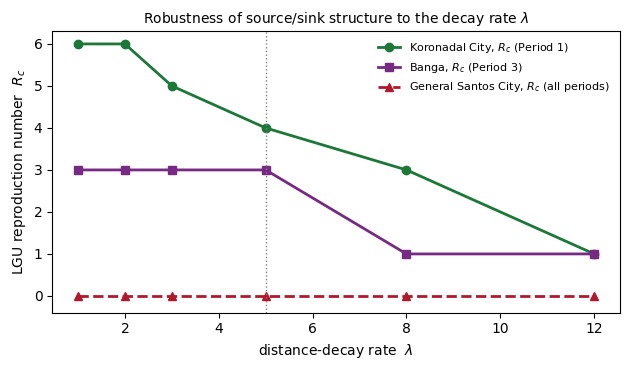

In [24]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6.4, 3.8))
ax.plot(lam_x, kor, 'o-',  color="#1b7837", lw=2, label="Koronadal City, $\mathrm{LOI}$ (Period 1)")
ax.plot(lam_x, ban, 's-',  color="#762a83", lw=2, label="Banga, $\mathrm{LOI}$ (Period 3)")
ax.plot(lam_x, gen, '^--', color="#b2182b", lw=2, label="General Santos City, $\mathrm{LOI}$ (all periods)")
ax.axvline(5, color="gray", ls=":", lw=1)
ax.set_xlabel("distance-decay rate  $\\lambda$")
ax.set_ylabel("LGU out-degree index  $\mathrm{LOI}$")
ax.set_title("Robustness of source/sink structure to the decay rate $\\lambda$", fontsize=10)
ax.legend(fontsize=8, frameon=False); ax.set_ylim(-0.4, None); fig.tight_layout()
fig.savefig(FIGDIR / "kernel_robustness.png", dpi=200); plt.show()

## 15. Smoothing-window sensitivity (Table 8)

Reviewer-requested check: re-estimate onsets on series smoothed at **14 / 30 / 60**-day
spans and confirm the onset *ordering* (which drives the reconstruction) is stable.
Writes `smoothing_sensitivity.csv`. Primary study area only; onsets here are
Python-native (they do not bit-match the shipped Python onsets), so this is an
ordering-stability check, not a re-derivation of the main-analysis onsets.


In [25]:
import numpy as np, pandas as pd
from scipy.stats import spearmanr

merged_raw, _ = merge_and_smooth()                 # unsmoothed merged daily series
spans = [14, 30, 60]
onset_by_span = {sp: extract_onsets(
        np.column_stack([moving_average(merged_raw[:, j], sp) for j in range(N)]),
        n_starts=512) for sp in spans}
base = onset_by_span[60]

rows = []
for sp in spans:
    rec = {"span": sp}
    for K in range(len(PERIODS)):
        a, b = onset_by_span[sp][:, K], base[:, K]
        m = np.isfinite(a) & np.isfinite(b)
        rec[f"rho_vs60_P{K+1}"] = 1.0 if sp == 60 else round(float(spearmanr(a[m], b[m]).correlation), 3)
        col = np.where(np.isfinite(onset_by_span[sp][:, K]), onset_by_span[sp][:, K], np.inf)
        rec[f"earliest_P{K+1}"] = CITIES[int(np.argmin(col))].title()
    rows.append(rec)

smooth_df = pd.DataFrame(rows)
smooth_df.to_csv(OUTDIR / "smoothing_sensitivity.csv", index=False)
print("Onset ordering is stable across the 30-60 day range; earliest-onset source LGUs invariant.")
smooth_df

Onset ordering is stable across the 30-60 day range; earliest-onset source LGUs invariant.


,span,rho_vs60_P1,earliest_P1,rho_vs60_P2,earliest_P2,rho_vs60_P3,earliest_P3
0,14,0.972,Tupi,0.870,Koronadal City,0.711,Surallah
1,30,0.986,Tupi,0.889,Norala,0.596,Tupi
2,60,1.000,Tupi,1.000,Tupi,1.000,Surallah


## 16. Onset-threshold robustness (Table 9)

Re-estimate onsets and re-run the ensemble for the per-capita outbreak threshold
theta in {10, 25, 50, 100} per 100,000 (theta=25 is the main analysis). Confirms the
source/sink partition (General Santos terminal, Koronadal a leading P1-2 source) is
not an artefact of the threshold constant. Writes `onset_threshold.csv`.


In [26]:
import numpy as np, pandas as pd
from scipy.optimize import minimize

def onsets_at_theta(smoothed, theta, n_starts=2048):
    """Onsets (Eqs. 1-3) at an arbitrary per-capita threshold theta per 100,000."""
    pp = POPULATION * (theta / 100000.0)
    bnds = [(0, None), (0.005, None), (0, None), (0, None)]
    On = np.zeros((N, len(PERIODS)))
    for K, (a, b) in enumerate(PERIODS):
        cum = np.cumsum(smoothed[a:b, :], axis=0); t = np.arange(cum.shape[0], dtype=float)
        for i in range(N):
            cd = cum[:, i]; G = _sobol_starts(n_starts, cd)
            x0 = G[np.argmin([_cost(g, t, cd) for g in G])]
            r = minimize(_cost, x0, args=(t, cd), method="L-BFGS-B", bounds=bnds, options={"maxiter": 5000})
            dyn = DynK(t, r.x); hit = np.where(dyn >= pp[i])[0]
            On[i, K] = hit[0] if hit.size else np.inf
    NOt = np.zeros_like(On)
    for j in range(len(PERIODS)):
        col = On[:, j]; fin = col[np.isfinite(col)]
        NOt[:, j] = col - (fin.min() if fin.size else 0.0)
    return NOt

gid = CITIES.index("GENERAL SANTOS CITY")
rows = []
for th in [10, 25, 50, 100]:
    NOth = NO if th == 25 else onsets_at_theta(smoothed, th)
    res_th = epidemic_forest_ensemble(smoothed, NOth, kMax=KMAX, seed=SEED)
    def dom(K):
        Rc = res_th[K]["R_c"]; i = int(np.argmax(Rc)); return f"{CITIES[i].title()} ({int(Rc[i])})"
    rows.append({"theta_per_100k": th,
                 "dominant_P1_P2_P3": " / ".join(dom(K) for K in range(len(PERIODS))),
                 "GenSan_Rc": "/".join(str(int(res_th[K]["R_c"][gid])) for K in range(len(PERIODS))),
                 "Rt": "/".join(f"{res_th[K]['global_Rt']:.1f}" for K in range(len(PERIODS)))})
thr_df = pd.DataFrame(rows); thr_df.to_csv(OUTDIR / "onset_threshold.csv", index=False)
thr_df

/Users/jayroldarcede/miniforge3/envs/pinnsir_arm/lib/python3.10/site-packages/scipy/stats/_qmc.py:993: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sample = self._random(n, workers=workers)
/var/folders/b9/xl2nlsfs37lgvh5jgg53rpn40000gn/T/ipykernel_5296/3562808542.py:7: RuntimeWarning: overflow encountered in power
  return C1 / (1.0 + C2 * np.exp(-C3 * (t - C4))) ** (1.0 / C2)
/var/folders/b9/xl2nlsfs37lgvh5jgg53rpn40000gn/T/ipykernel_5296/3562808542.py:7: RuntimeWarning: overflow encountered in exp
  return C1 / (1.0 + C2 * np.exp(-C3 * (t - C4))) ** (1.0 / C2)
/var/folders/b9/xl2nlsfs37lgvh5jgg53rpn40000gn/T/ipykernel_5296/3562808542.py:7: RuntimeWarning: overflow encountered in multiply
  return C1 / (1.0 + C2 * np.exp(-C3 * (t - C4))) ** (1.0 / C2)


,theta_per_100k,dominant_P1_P2_P3,GenSan_Rc,Rt
0,10,Koronadal City (4) / Koronadal City (2) / Tant...,0/0/0,5.0/0.5/1.0
1,25,Koronadal City (4) / Koronadal City (3) / Bang...,0/0/0,5.0/1.4/5.0
2,50,Koronadal City (3) / Koronadal City (2) / Koro...,0/0/0,5.0/1.0/5.0
3,100,Koronadal City (4) / Koronadal City (3) / Tant...,0/1/0,5.0/1.0/5.0
